In [15]:
import os 
import configparser

In [16]:
config_path = "configs/Training_config2.ini"
config_read = configparser.ConfigParser()
config_read.read(config_path)

['configs/Training_config2.ini']

In [17]:
for sect in config_read.sections():
    print('Title:', sect)
    for k,v in config_read.items(sect):
        print(' {} = {}'.format(k,v))
    print()

Title: TrainingInfo
 traindataset = ['jaadall_with_c_g/train/']
 loss = BCE
 save_model_folder_acc = training_results/best_val_acc/
 save_model_folder_f1 = training_results/best_val_f1/
 batch_size = 500
 stratifiedkfold_random_state = 1
 graph_seed = 2676
 1dcnn_seed = 2726



In [18]:
import json
train_folder = json.loads(config_read.get("TrainingInfo", "traindataset").replace("'",'"'))
loss_name = config_read.get("TrainingInfo", "loss")
save_model_folder_acc = config_read.get("TrainingInfo", "save_model_folder_acc")
save_model_folder_f1 = config_read.get("TrainingInfo", "save_model_folder_f1")
batch_size = int(config_read.get("TrainingInfo", "batch_size"))
ran_2 = int(config_read.get("TrainingInfo", "stratifiedkfold_random_state"))

# Load training data

In [19]:
train_folder[0]

'jaadall_with_c_g/train/'

In [6]:
import numpy as np
root = 'preprocessed_data/'+train_folder[0]
x_k_train, y_k_train = np.load(root + 'x_k.npy'), np.load(root + 'y.npy')
x_t_train, y_t_train = np.load(root + 'x_t.npy'), np.load(root + 'y.npy')
x_c_train, y_c_train = np.load(root + 'x_c.npy'), np.load(root + 'y.npy')
x_g_train, y_g_train = np.load(root + 'x_g.npy'), np.load(root + 'y.npy')

In [7]:
len(y_k_train)

162254

In [8]:
x_g_train.shape

(162254, 2)

In [9]:
y_t = y_t_train
count_pos, count_neg = 0, 0
for label in y_t:
    if label == [1.0]:
        count_pos+=1
    else:
        count_neg+=1
print('Negative class is minority class')
print('Imbalance ratio: {0}:{1}'.format(str(round(count_pos/len(y_t),2)), str(round(count_neg/len(y_t),2))))
print('Number of sample deficit: {0}'.format(str(count_pos-count_neg)))

Negative class is minority class
Imbalance ratio: 0.09:0.91
Number of sample deficit: -133776


# predict each val fold's FC output

In [20]:
from model_evaluation.model_predictions import predict_graph, predict_1dcnn_addfeatures, predict_gru
import numpy as np

In [11]:
import random
from sklearn.model_selection import train_test_split
def retrieve_pos_neg(x_train, y_train):
    pos_indices = np.squeeze(y_train==1)
    neg_indices = np.squeeze(y_train==0)

    # split pos/neg
    x_pos_train = x_train[pos_indices]
    y_pos_train = y_train[pos_indices]

    x_neg_train = x_train[neg_indices]
    y_neg_train = y_train[neg_indices]

    x_shuffle_neg_indices = [i for i in range(len(y_neg_train))]
    np.random.seed(10)
    np.random.shuffle(x_shuffle_neg_indices)
    
    random.seed(38)
    shuffle_indices = random.sample(x_shuffle_neg_indices, len(y_pos_train)*5)
    
    
#     x_neg_samples = x_neg_train[sampled_indices]
#     y_neg_samples = y_neg_train[sampled_indices]
    
#     merge_x = np.concatenate([x_pos_train, x_neg_samples])
#     merge_y = np.concatenate([y_pos_train, y_neg_samples])
    
    return shuffle_indices, x_pos_train, y_pos_train, x_neg_train, y_neg_train

In [12]:
def merge_x_y(i, shuffle_indices, x_pos_train, y_pos_train, x_neg_train, y_neg_train):
    pos_num = len(y_pos_train)
    neg_fold_idxs = [i*pos_num, i*pos_num+pos_num]
    neg_idx_start, neg_idx_end = neg_fold_idxs[0], neg_fold_idxs[1]
    sampled_indices=shuffle_indices[neg_idx_start:neg_idx_end]
    
    x_neg_samples = x_neg_train[sampled_indices]
    y_neg_samples = y_neg_train[sampled_indices]
    
    
    merge_x = np.concatenate([x_pos_train, x_neg_samples])
    merge_y = np.concatenate([y_pos_train, y_neg_samples])
    
#     alpha = count_imbalance(merge_y)
    return merge_x, merge_y
    
    

In [13]:
from sklearn.model_selection import StratifiedKFold
import torch

def get_val_probs(predict_model, model_folder, X_data, y_data, is_m2 = False, g_data = None, c_data_sizes=None):
    
    if torch.cuda.is_available():
        device = torch.device('cuda')
    else:
        device = torch.device('cpu')
    
    val_preds = []
    val_gts = []
    ensemble_fcs = []
    
    for i in range(5):
        sub_model_folder = model_folder+'fold_{0}/'.format(i+1)
        """
        get val
        """
        shuffle_indices, x_pos_train, y_pos_train, x_neg_train, y_neg_train = retrieve_pos_neg(X_data, y_data)
        merge_x, merge_y = merge_x_y(i, shuffle_indices, x_pos_train, y_pos_train, x_neg_train, y_neg_train)
        _, X_val, _, y_val = train_test_split(merge_x, merge_y, test_size=0.20, random_state=42)
        X_val = torch.FloatTensor(X_val)
        y_val = torch.FloatTensor(y_val)
        val_gts.append(y_val)
        
        if not is_m2:
            FC_outputs = predict_model(sub_model_folder, X_val, device, 'f1').cpu().detach()#FC_outputs: outputs of the last FC
        else:
            """
            get g val the same as x_val
            """
            shuffle_indices, g_pos_train, _, g_neg_train, _ = retrieve_pos_neg(g_data, y_data)
            merge_g, merge_y = merge_x_y(i, shuffle_indices, g_pos_train, y_pos_train, g_neg_train, y_neg_train)
            
            _, g_val, _, _ = train_test_split(merge_g, merge_y, test_size=0.20, random_state=42)
            g_val = torch.FloatTensor(g_val)
    
            g_data_size = g_val.shape
            
            FC_outputs = predict_gru(c_data_sizes, g_data_size, sub_model_folder, X_val, g_val, device, 'f1').to('cpu')
        
        probs = torch.sigmoid(FC_outputs)
        preds = torch.round(probs)
        val_preds.append(preds)
        ensemble_fcs.append(FC_outputs)
    return ensemble_fcs, val_preds, val_gts

In [14]:
model_folder = "best_val_f1/"
ensemble_x1, val_preds_x1, val_gts_x1 = get_val_probs(predict_graph, model_folder, x_k_train, y_k_train)
ensemble_x1 = torch.cat(ensemble_x1, axis=0)

/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


In [15]:
ensemble_x3, val_preds_x3, val_gts_x3 = get_val_probs(predict_1dcnn_addfeatures, model_folder, x_t_train, y_t_train)
ensemble_x3 = torch.cat(ensemble_x3, axis=0)

/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


In [17]:
c_data_sizes = [(16, 1), (16, 1)]
ensemble_x2, val_preds_x2, val_gts_x2 = get_val_probs(predict_gru, model_folder, x_c_train, y_c_train, True, x_g_train, c_data_sizes)
ensemble_x2 = torch.cat(ensemble_x2, axis=0)

torch.Size([5696, 16, 2]) torch.Size([5696, 2])
torch.Size([11392, 16, 1]) torch.Size([5696, 2])
torch.Size([5696, 16, 2]) torch.Size([5696, 2])
torch.Size([11392, 16, 1]) torch.Size([5696, 2])


/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b = torch.tensor(x2)
/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.s

torch.Size([5696, 16, 2]) torch.Size([5696, 2])
torch.Size([11392, 16, 1]) torch.Size([5696, 2])
torch.Size([5696, 16, 2]) torch.Size([5696, 2])
torch.Size([11392, 16, 1]) torch.Size([5696, 2])
torch.Size([5696, 16, 2]) torch.Size([5696, 2])
torch.Size([11392, 16, 1]) torch.Size([5696, 2])


In [18]:
val_preds_x1 = torch.cat(val_preds_x1, axis=0)
val_preds_x2 = torch.cat(val_preds_x2, axis=0)
val_preds_x3 = torch.cat(val_preds_x3, axis=0)

In [19]:
val_gts_x1 = np.concatenate(val_gts_x1, axis=0)
val_gts_x2 = np.concatenate(val_gts_x2, axis=0)
val_gts_x3 = np.concatenate(val_gts_x3, axis=0)

In [20]:
x1_mistake_idx_li = []
x2_mistake_idx_li = []
x3_mistake_idx_li = []

for i, v in enumerate(val_gts_x1):
    v = int(v)
    x1_pred = int(val_preds_x1[i])
    x2_pred = int(val_preds_x2[i])
    x3_pred = int(val_preds_x3[i])
    if x1_pred!=v:
        x1_mistake_idx_li.append(i)
    if x2_pred!=v:
        x2_mistake_idx_li.append(i)
    if x3_pred!=v:
        x3_mistake_idx_li.append(i)

/tmp/ipykernel_659871/3400760797.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  v = int(v)


In [21]:
len(x1_mistake_idx_li)/len(val_gts_x1)

0.22787921348314608

In [22]:
len(x2_mistake_idx_li)/len(val_gts_x1)

0.38697331460674156

In [23]:
len(x3_mistake_idx_li)/len(val_gts_x1)

0.2502457865168539

In [24]:
def overlapping_mistake_ratio(a,b):
    return len(set(a) & set(b)), len(list(set(a)) + list(set(b)))

In [25]:
a = x1_mistake_idx_li
b = x2_mistake_idx_li
print(overlapping_mistake_ratio(a,b))
# print(len(set(a) & set(b)) / len(a), len(set(a) & set(b)) / len(b))

(2671, 17511)


In [26]:
a = x1_mistake_idx_li
b = x3_mistake_idx_li
print(overlapping_mistake_ratio(a,b))
print(len(set(a) & set(b)) / len(a), len(set(a) & set(b)) / len(b))

(2546, 13617)
0.3922958397534669 0.3572330573874


In [27]:
a = x2_mistake_idx_li
b = x3_mistake_idx_li
print(overlapping_mistake_ratio(a,b))
print(len(set(a) & set(b)) / len(a), len(set(a) & set(b)) / len(b))

(2445, 18148)
0.2218491969875692 0.3430615967447734


In [28]:
def acc(preds, targets):
    train_corrects = 0
    train_corrects += (preds == targets).sum().item()
    acc = train_corrects/len(targets)
    return acc

In [29]:
acc(np.array(val_preds_x1), val_gts_x1)

0.7721207865168539

In [30]:
acc(np.array(val_preds_x2.detach().numpy()), val_gts_x2)

0.6130266853932584

In [31]:
acc(np.array(val_preds_x3), val_gts_x3)

0.7497542134831461

In [18]:
# val_gts_x1 == val_gts_x2

In [19]:
# val_gts_x2 == val_gts_x3

# split (FC_output: x1, x2, x3 also called lv1 features) Data again to Train/Val 

In [32]:
import numpy as np
from sklearn.model_selection import train_test_split

In [33]:
ran_3 = 70
test_ratio=0.2
X_train_x1, X_val_x1, y_train_x1, y_val_x1 = train_test_split(ensemble_x1, val_gts_x1, test_size=test_ratio, random_state=ran_3)
X_train_x2, X_val_x2, y_train_x2, y_val_x2 = train_test_split(ensemble_x2, val_gts_x1, test_size=test_ratio, random_state=ran_3)
X_train_x3, X_val_x3, y_train_x3, y_val_x3 = train_test_split(ensemble_x3, val_gts_x1, test_size=test_ratio, random_state=ran_3)

In [34]:
print(X_train_x1.shape, X_train_x2.shape, X_train_x3.shape, y_train_x1.shape)

torch.Size([22784, 1]) torch.Size([22784, 1]) torch.Size([22784, 1]) (22784, 1)


In [35]:
X_train_x1

tensor([[ 0.1159],
        [-0.2443],
        [-1.1103],
        ...,
        [ 1.0865],
        [ 0.6665],
        [ 0.1383]])

# Train ensemble learning - on lv1 features

In [36]:
# Train/Test: ensemble_probs_x1, ensemble_probs_x2, ensemble_probs_x3
# Test: X_test_k, X_test_s, X_test_t

In [37]:
def count_imbalance(y_t):
    count_pos, count_neg = 0, 0
    for label in y_t:
        if label == [1.0]:
            count_pos+=1
        else:
            count_neg+=1
    if count_pos>count_neg:
        print('Negative class is minority class')
    else:
        print('Positive class is minority class')
        
    print('Pos:Neg = {0}:{1}'.format(str(round(count_pos/len(y_t),2)), str(round(count_neg/len(y_t),2))))
    print('Number of sample deficit: {0}'.format(str(abs(count_pos-count_neg))))
    return count_pos/(count_pos+count_neg)

# alpha = count_imbalance(y_train_x1)

In [38]:
alpha = count_imbalance(val_gts_x1)

Positive class is minority class
Pos:Neg = 0.5:0.5
Number of sample deficit: 0


In [39]:
import os
import torch 
import numpy as np
import utils.data_loader as Dataset
from torch.utils.data import DataLoader
import models.ensemble as EN
# import models.onedcnn_model_second as onedcnn_model_second
# torch.backends.cudnn.enabled=False

In [40]:
save_model_folder_acc, save_model_folder_f1 = 'training_results/best_val_acc/aggregate/', 'training_results/best_val_f1/aggregate/'

if not os.path.exists(save_model_folder_acc):
    os.mkdir(save_model_folder_acc)

if not os.path.exists(save_model_folder_f1):
    os.mkdir(save_model_folder_f1)

In [41]:
from torch.utils.data import Dataset, DataLoader
class leveloneData_ensemble(Dataset):
    
    def __init__(self, X_data, y_data):
        self.X_data = X_data
        self.y_data = y_data
        
    def __getitem__(self, index):
        return self.X_data[index], self.y_data[index]
        
    def __len__ (self):
        return len(self.X_data)

Dataloader seed: 2726
[INFO]: Epoch 2 of 200
Training loss: 0.330, training acc: 82.000
Validation loss: 0.322, validation acc: 83.000
--------------------------------------------------

Best validation acc: 83.0

Saving best model for epoch: 2


Best validation f1: 0.83

Saving best model for epoch: 2

[INFO]: Epoch 3 of 200
Training loss: 0.317, training acc: 82.000
Validation loss: 0.311, validation acc: 82.000
--------------------------------------------------
[INFO]: Epoch 4 of 200
Training loss: 0.307, training acc: 82.000
Validation loss: 0.302, validation acc: 82.000
--------------------------------------------------
[INFO]: Epoch 5 of 200
Training loss: 0.300, training acc: 81.000
Validation loss: 0.295, validation acc: 82.000
--------------------------------------------------
[INFO]: Epoch 6 of 200
Training loss: 0.294, training acc: 81.000
Validation loss: 0.290, validation acc: 82.000
--------------------------------------------------
[INFO]: Epoch 7 of 200
Training loss: 0

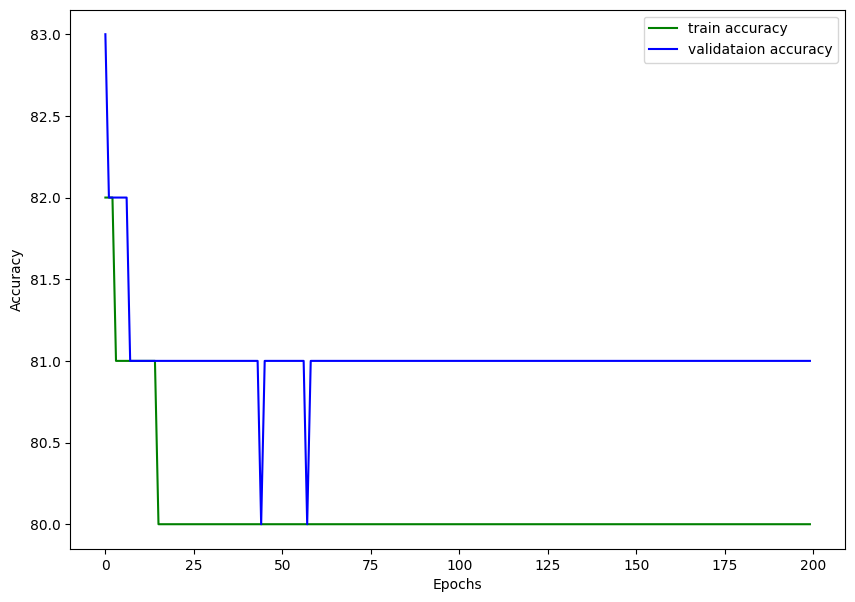

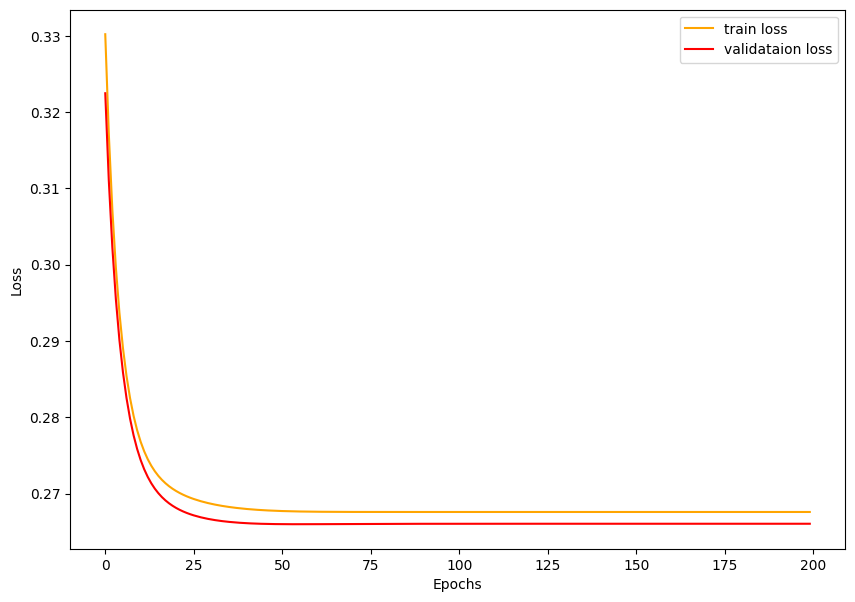

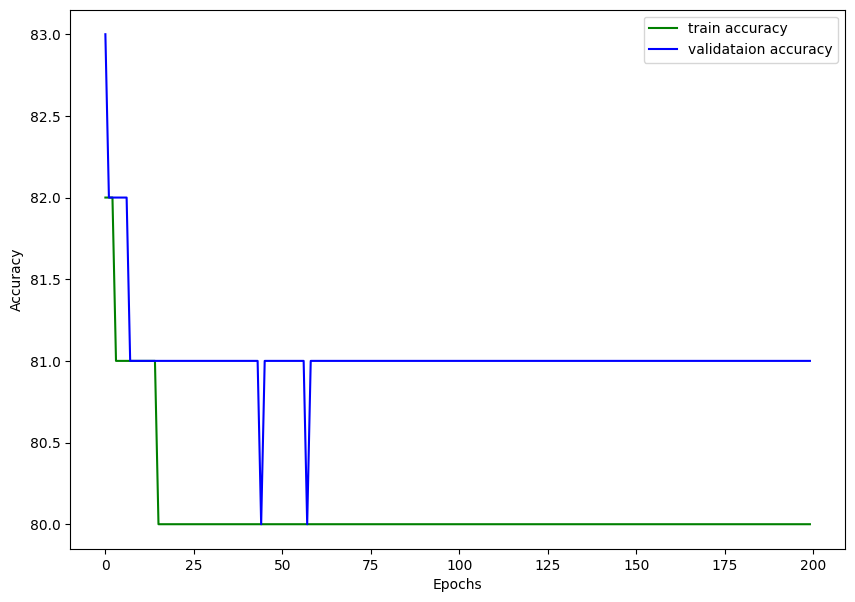

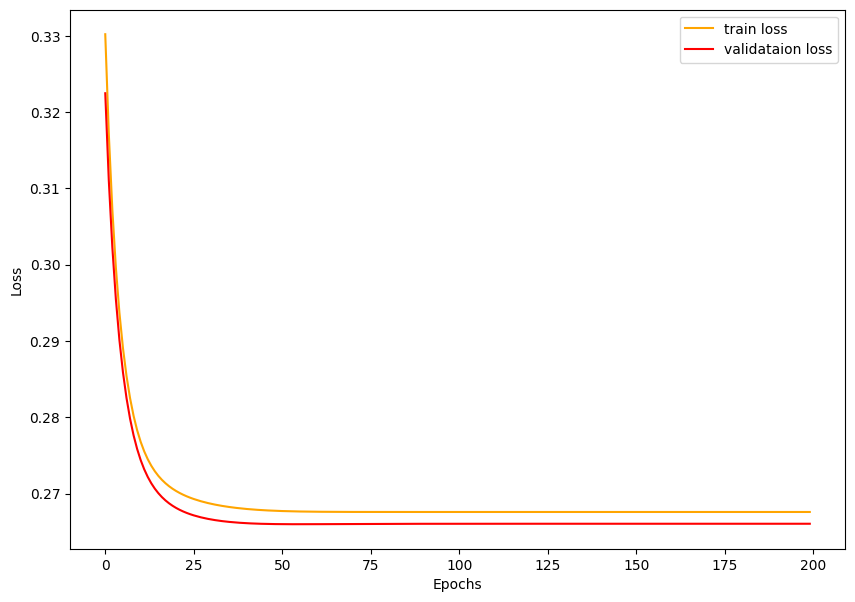

In [42]:
# torch.backends.cudnn.enabled = False
X_train = torch.concat((torch.FloatTensor(X_train_x1.detach()),torch.FloatTensor(X_train_x2.detach()), torch.FloatTensor(X_train_x3.detach())), dim=1)
X_val = torch.concat((torch.FloatTensor(X_val_x1.detach()),torch.FloatTensor(X_val_x2.detach()),torch.FloatTensor(X_val_x3.detach())), dim=1)
y_train =  torch.FloatTensor(y_train_x1)
y_val =  torch.FloatTensor(y_val_x1)

train_data = leveloneData_ensemble(X_train, y_train_x1)
val_data = leveloneData_ensemble(X_val,  y_val_x1)

train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True,drop_last=True)
val_loader = DataLoader(dataset=val_data, batch_size=batch_size, drop_last=True)

EN.train_perceptron_aggregate(train_loader, val_loader, save_model_folder_acc, save_model_folder_f1, loss_name, alpha)

# Test on testset
* (1) we have 5-fold models in each pipeline model (i.e, Graph, GRU, 1dcnn)
* (2) we predict FC_output for our X_test using all 5x3pipelines models.
* (3) we multiply y_test for 5 times as well to match number of samples in (2)
* (4) from (2) we collect ensemble_x and from (3) we collect new y_test
* (5) we test ensemble learner on ensemble_x and calculate its performance stats by comparing ground truth labels new y_test

In [21]:
def get_test_prob(predict_model, model_folder, X_test, is_m2 = False, g_data = None, c_data_sizes=None):
    folds = 5
    ensemble_test = []
    test_confs = []
    if torch.cuda.is_available():
        device = torch.device('cuda')
    else:
        device = torch.device('cpu')   
    for i in range(folds):
        sub_model_folder = model_folder+'fold_{0}/'.format(i+1)
        if not is_m2:
            FC_outputs = predict_model(sub_model_folder, X_test, device, 'f1').cpu().detach()
        else:
            g_data_size = g_data.shape
            FC_outputs = predict_gru(c_data_sizes, g_data_size, sub_model_folder, X_test, g_data, device, 'f1').to('cpu').detach()
            
        ensemble_test.append(FC_outputs)
        probs = torch.sigmoid(FC_outputs)
        test_confs.extend(probs)
    return ensemble_test, test_confs
    

In [22]:
import numpy as np
root = 'preprocessed_data/jaadall_with_c_g/test/'
x_k_test, y_k_test = np.load(root + 'x_k.npy'), np.load(root + 'y.npy')
x_t_test, y_t_test  = np.load(root + 'x_t.npy'), np.load(root + 'y.npy')
x_c_test, y_c_test = np.load(root + 'x_c.npy'), np.load(root + 'y.npy')
x_g_test, y_g_test = np.load(root + 'x_g.npy'), np.load(root + 'y.npy')

In [23]:
# count_imbalance(y_k_test)

In [24]:
len(y_k_test)

108887

In [25]:
x_k_test.shape, y_k_test.shape

((108887, 16, 14, 2), (108887, 1))

In [26]:
model_folder = 'best_val_f1/'

In [27]:
import torch
c_data_sizes = [(16, 1), (16, 1)]
ensemble_test_k, test_confs_k =get_test_prob(predict_graph, model_folder, x_k_test)
ensemble_test_s, test_confs_s =get_test_prob(predict_gru, model_folder, x_c_test, True, x_g_test, c_data_sizes)
ensemble_test_t, test_confs_t =get_test_prob(predict_1dcnn_addfeatures, model_folder, x_t_test)

/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


torch.Size([108887, 16, 2]) torch.Size([108887, 2])
torch.Size([217774, 16, 1]) torch.Size([108887, 2])


/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b = torch.tensor(x2)
/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.s

torch.Size([108887, 16, 2]) torch.Size([108887, 2])
torch.Size([217774, 16, 1]) torch.Size([108887, 2])
torch.Size([108887, 16, 2]) torch.Size([108887, 2])
torch.Size([217774, 16, 1]) torch.Size([108887, 2])
torch.Size([108887, 16, 2]) torch.Size([108887, 2])
torch.Size([217774, 16, 1]) torch.Size([108887, 2])
torch.Size([108887, 16, 2]) torch.Size([108887, 2])
torch.Size([217774, 16, 1]) torch.Size([108887, 2])


/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


# macro

In [28]:
def predict_ensemble_aggregate(models_folder, x, device, best_by):
    model_root = 'training_results/'+models_folder+'aggregate/'
    if not best_by:
        model_path = model_root+'best_aggregate_model.pth'
    else:
        model_path = model_root+'best_aggregate_model_{0}.pth'.format('by'+best_by)
    print(model_path)
    model = EN.Aggregate().to(device)
    print(model.fc.weight)
    x = torch.FloatTensor(x).to(device)
    checkpoint = torch.load(model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    y_hat = model(x)
    return y_hat 

In [29]:
def acc(preds, targets):
    train_corrects = 0
    train_corrects += (preds == targets).sum().item()
    acc = train_corrects/len(targets)
    return acc

In [30]:
ensemble_test_k = np.concatenate(ensemble_test_k,axis=0)
ensemble_test_s = np.concatenate(ensemble_test_s,axis=0)
ensemble_test_t = np.concatenate(ensemble_test_t,axis=0)
ensemble_x_test = np.concatenate([ensemble_test_k, ensemble_test_s, ensemble_test_t], axis=1)
print(ensemble_x_test.shape)

y_test = np.concatenate([y_k_test]*5, axis=0)
y_test.shape

(544435, 3)


(544435, 1)

# ablation analysis

training_results/best_val_f1/aggregate/best_aggregate_model_byf1.pth
Parameter containing:
tensor([[ 0.3157, -0.2475,  0.4371]], device='cuda:0', requires_grad=True)


/tmp/ipykernel_688700/748689495.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


fp_rate: 0.03
fn_rate: 0.74
acc: 0.82
auc: 0.86
f1: 0.64
pr: 0.62
re: 0.78
confidence: 


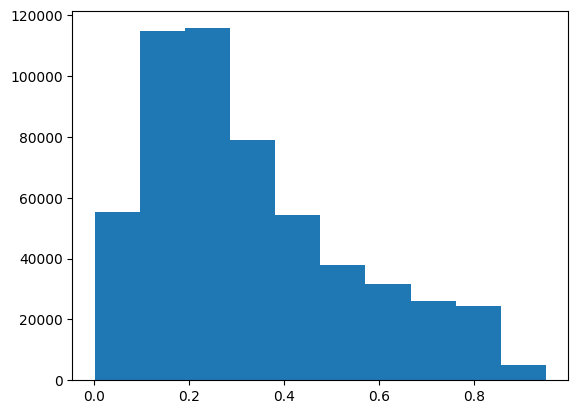

Confusion martrix: 


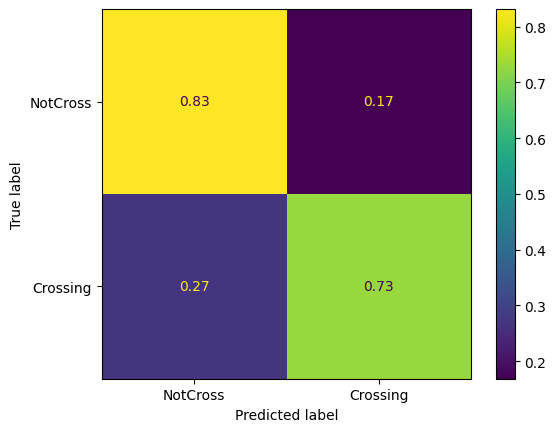

In [31]:
# from model_evaluation.model_predictions import predict_ensemble_aggregate
model_folder = 'best_val_f1/'
import models.ensemble as EN
from model_evaluation.performance_scores import get_precision_recall_F1, calculate_acc
from sklearn import metrics
import matplotlib.pyplot as plt
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
ensemble_x_test = torch.tensor(ensemble_x_test)
FC_outputs = predict_ensemble_aggregate(model_folder, ensemble_x_test.cpu(), device, 'f1').cpu().detach()      
probs = torch.sigmoid(FC_outputs)
preds = torch.round(probs)
tn, fp, fn, tp = metrics.confusion_matrix(preds.cpu(), y_test).ravel()
fp_rate = fp/(fp+tn)
fn_rate = fn/(fn+tp) 
test_acc = acc(np.array(preds),y_test)
# y_test = torch.tensor(y_test).to(device)
# probs, preds, y_test = probs.to(device), preds.to(device), y_test.to(device)

p, r, f1, auc = get_precision_recall_F1(preds, y_test, probs)
        
print('fp_rate: {0:.2f}'.format(fp_rate))
print('fn_rate: {0:.2f}'.format(fn_rate))
print('acc: {0:.2f}'.format(test_acc))
print('auc: {0:.2f}'.format(float(auc)))
print('f1: {0:.2f}'.format(float(f1)))
print('pr: {0:.2f}'.format(float(p)))
print('re: {0:.2f}'.format(float(r)))
print('confidence: ')
probs = probs.cpu().detach().numpy()
probs_li = np.squeeze(probs).tolist()
plt.hist(probs_li)
plt.show()
print('Confusion martrix: ')
# preds = preds.astype(int)
preds_li = np.squeeze(preds).tolist()
confusion_matrix = metrics.confusion_matrix(y_test,preds, normalize='true')
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ['NotCross', 'Crossing'])
cm_display.plot()
plt.show()


In [32]:
import json

# Open and read the JSON file
with open('JAADall_results.json', 'r') as file:
    results = json.load(file)

# Print the data
print(results.keys())

dict_keys(['x3', 'x1', 'x2', 'x1_x2', 'x1_x3', 'x2_x3'])


In [33]:
y_test = np.squeeze(y_test).tolist()

In [34]:
type(probs_li), type( preds_li), type(y_test)

(list, list, list)

In [35]:
results['x1_x2_x3'] = {'probs':probs_li, 'preds': preds_li, 'test_gts': y_test}

In [36]:
import json
with open('JAADall_results.json', 'w') as f:
    json.dump(results, f)

In [37]:
for k in results.keys():
    print(len(results[k]['preds']))

544435
544435
544435
544435
544435
544435
544435


In [38]:
results.keys()

dict_keys(['x3', 'x1', 'x2', 'x1_x2', 'x1_x3', 'x2_x3', 'x1_x2_x3'])